In [3]:
from typing import TypedDict,Dict
from langgraph.graph import StateGraph,START,END

C:\Users\Deepp\AppData\Roaming\Python\Python314\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [4]:
class AgentState(TypedDict):
    num1:int
    num2:int
    num3:int
    num4:int
    operator1:str
    operator2:str
    result:int
    result2:int


In [5]:
def Add(state: AgentState)->AgentState:
    state['result']=state['num1']+state['num2']
    return state
def Subtract(state: AgentState)->AgentState:
    state['result']=state['num1']-state['num2']
    return state
def Add2(state:AgentState)->AgentState:
    state['result']=state['num3']+state['num4']
    return state
def Subtract2(state:AgentState)->AgentState:
    state['result2']=state['num3']-state['num4']
    return state

def router1(state:AgentState)->AgentState:
    if state['operator1']=='+':
        return 'add1'
    else:
        return 'subtract1'
    
def router2(state:AgentState)->AgentState:
    if state['operator2']=='+':
        return 'add2'
    else:
        return 'subtract2'

In [6]:
graph=StateGraph(AgentState)

graph.add_node('add1',Add)
graph.add_node('subtract1',Subtract)    
graph.add_node('add2',Add2)
graph.add_node('subtract2',Subtract2)
graph.add_conditional_edges(
    START,
    router1,
    {
        'add1': 'add1',
        'subtract1': 'subtract1'
    }
)
graph.add_conditional_edges(
    'add1',
    router2,
    {
        'add2': 'add2',
        'subtract2': 'subtract2'
    }
)
graph.add_conditional_edges(
    'subtract1',
    router2,
    {
        'add2': 'add2',
        'subtract2': 'subtract2'
    }
)
graph.add_edge('add2',END)
graph.add_edge('subtract2',END)

app=graph.compile()

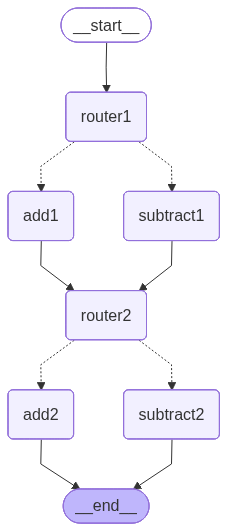

In [9]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
result=app.invoke({'num1':10,'num2':5,'num3':20,'num4':10,'operator1':'+','operator2':'-'})

In [8]:
print(result)

{'num1': 10, 'num2': 5, 'num3': 20, 'num4': 10, 'operator1': '+', 'operator2': '-', 'result': 15, 'result2': 10}
